# Load Type Classification for a Power System

## Objective
Predict the `Load_Type` of a power system (`Light_Load`, `Medium_Load`, `Maximum_Load`) from
operational energy-consumption measurements. This is a multiclass classification problem.

## Dataset
Steel Industry Energy Consumption (DAEWOO Steel, 2018, 15-minute resolution). The provided copy
contains injected missing values and out-of-range noise, so data cleaning is an integral part of
the task.

## Validation strategy
Following the brief, the last month (December 2018) is held out as the test set. Models are tuned
on the January to November data using stratified cross-validation.

## Summary of design choices
| Step | Choice |
|---|---|
| Test set | December 2018 (temporal hold-out) |
| Cross-validation | StratifiedKFold(5) inside GridSearchCV, scoring macro-F1 |
| Primary metric | Macro-F1 (moderate class imbalance) |
| Corrupted NSM | Reconstructed from the timestamp (seconds from midnight) |
| Power factor above 100 | Treated as invalid, set to NaN, then imputed |
| Imputation | Median, fitted on training folds only |
| Outliers | IQR winsorisation, fitted on training folds only |
| Lag features | None; each row is an independent sample |
| Class imbalance | class_weight='balanced' where supported |
| Models compared | Dummy, Logistic Regression, KNN, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM, SVM, Gaussian NB |

## 1. Setup and Imports

In [1]:
import warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
print('Libraries loaded.')

Libraries loaded.


## 2. Load Data and Initial Inspection

In [2]:
DATA_PATH = 'data/load_data.csv'
df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (35041, 9)


,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date_Time                             35041 non-null  object 
 1   Usage_kWh                             33482 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  34165 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  33885 non-null  float64
 4   CO2(tCO2)                             34586 non-null  float64
 5   Lagging_Current_Power_Factor          34691 non-null  float64
 6   Leading_Current_Power_Factor          33570 non-null  float64
 7   NSM                                   34586 non-null  float64
 8   Load_Type                             35041 non-null  object 
dtypes: float64(7), object(2)
memory usage: 2.4+ MB


In [4]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,33482.0,30.873061,41.415015,0.0,3.310,5.29,53.560000,435.019069
Lagging_Current_Reactive.Power_kVarh,34165.0,14.704573,20.342721,0.0,2.340,5.18,23.510000,262.630718
Leading_Current_Reactive_Power_kVarh,33885.0,4.386097,9.090181,0.0,0.000,0.00,2.298558,78.809000
CO2(tCO2),34586.0,0.012947,0.019726,0.0,0.000,0.00,0.020000,0.188166
Lagging_Current_Power_Factor,34691.0,90.740871,39.745395,0.0,66.295,90.08,100.000000,299.996814
Leading_Current_Power_Factor,33570.0,94.926552,49.826872,0.0,99.800,100.00,100.000000,299.969494
NSM,34586.0,48013.664032,34046.492333,0.0,22500.000,45000.00,68400.000000,248821.810465


## 3. Data Quality Assessment

The dataset contains injected noise. The checks below cover (a) missing values, (b) physically
impossible values, and (c) duplicate timestamps.

In [5]:
# (a) Missing values
miss = pd.DataFrame({'missing': df_raw.isna().sum(),
                     'pct': (df_raw.isna().mean()*100).round(2)})
print('--- Missing values ---')
print(miss[miss['missing'] > 0].sort_values('missing', ascending=False))

--- Missing values ---
                                      missing   pct
Usage_kWh                                1559  4.45
Leading_Current_Power_Factor             1471  4.20
Leading_Current_Reactive_Power_kVarh     1156  3.30
Lagging_Current_Reactive.Power_kVarh      876  2.50
CO2(tCO2)                                 455  1.30
NSM                                       455  1.30
Lagging_Current_Power_Factor              350  1.00


In [6]:
# (b) Physically impossible values
#  - Power factor must lie in [0, 100]
#  - NSM (seconds from midnight) must lie in [0, 86400]
print('Lagging PF  > 100 :', int((df_raw['Lagging_Current_Power_Factor'] > 100).sum()))
print('Leading PF  > 100 :', int((df_raw['Leading_Current_Power_Factor'] > 100).sum()))
print('NSM > 86400       :', int((df_raw['NSM'] > 86400).sum()))
print('Any negative PF   :', int(((df_raw['Lagging_Current_Power_Factor'] < 0) |
                                  (df_raw['Leading_Current_Power_Factor'] < 0)).sum()))

# (c) Duplicate timestamps
print('Duplicate timestamps:', int(df_raw['Date_Time'].duplicated().sum()))

# How corrupted is NSM vs the actual time-of-day encoded in Date_Time?
_dt = pd.to_datetime(df_raw['Date_Time'], format='%d-%m-%Y %H:%M')
_tod = _dt.dt.hour*3600 + _dt.dt.minute*60
print('NSM inconsistent with timestamp (>60s off):',
      int(((df_raw['NSM'] - _tod).abs() > 60).sum()))

Lagging PF  > 100 : 3226
Leading PF  > 100 : 2685
NSM > 86400       : 1773
Any negative PF   : 0
Duplicate timestamps: 1


NSM inconsistent with timestamp (>60s off): 3414


### Findings
- Missing values are present in all seven numeric columns (roughly 1 to 4.5 percent each).
- Power factor values above 100 appear in thousands of rows; a power factor cannot exceed 100.
- `NSM` is heavily corrupted, but it represents seconds from midnight and is fully recoverable from `Date_Time`.
- There is one duplicate timestamp (`31-12-2018 20:00`).

## 4. Data Cleaning

Steps:
1. Parse `Date_Time`, sort chronologically, and drop the duplicate timestamp.
2. Set power factor values outside the valid range [0, 100] to NaN; they are imputed later.
3. Reconstruct `NSM` as `hour*3600 + minute*60` from the timestamp, which removes both the NSM noise and its missing values.

Median imputation, outlier capping, and scaling are intentionally left out of this step. They are
part of the modelling pipeline so that they are fitted on the training folds only, which prevents
data leakage.

In [7]:
def clean_data(df):
    df = df.copy()
    df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='%d-%m-%Y %H:%M')
    df = df.sort_values('Date_Time').reset_index(drop=True)
    # drop duplicate timestamps (keep first)
    df = df.drop_duplicates(subset='Date_Time', keep='first').reset_index(drop=True)
    # invalidate impossible power factors -> NaN
    for c in ['Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']:
        df.loc[(df[c] > 100) | (df[c] < 0), c] = np.nan
    # reconstruct NSM deterministically from the timestamp
    df['NSM'] = df['Date_Time'].dt.hour*3600 + df['Date_Time'].dt.minute*60
    return df

df = clean_data(df_raw)
print('After cleaning:', df.shape)
print('Date range:', df['Date_Time'].min(), '->', df['Date_Time'].max())
print('Remaining NSM out of range:', int((df['NSM'] > 86400).sum()))
df.head()

After cleaning: (35040, 9)
Date range: 2018-01-01 00:00:00 -> 2018-12-31 23:45:00
Remaining NSM out of range: 0


,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,2018-01-01 00:00:00,3.420000,3.46,0.0,0.0,70.30,NaN,0,Light_Load
1,2018-01-01 00:15:00,8.753692,2.95,0.0,0.0,73.21,100.0,900,Light_Load
2,2018-01-01 00:30:00,4.000000,4.46,0.0,0.0,66.77,100.0,1800,Light_Load
3,2018-01-01 00:45:00,3.240000,3.28,0.0,0.0,70.28,100.0,2700,Light_Load
4,2018-01-01 01:00:00,3.310000,3.56,0.0,0.0,68.09,100.0,3600,Light_Load


## 5. Exploratory Data Analysis

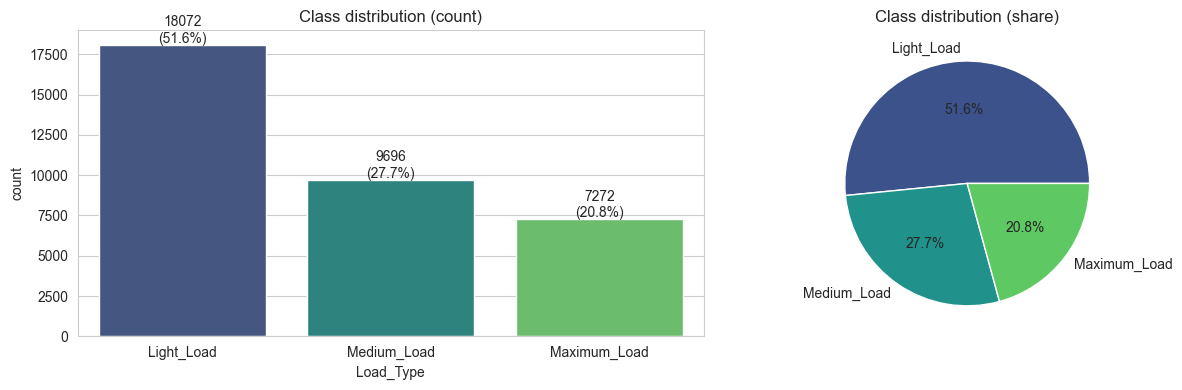

Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64


In [8]:
# Target distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
order = ['Light_Load', 'Medium_Load', 'Maximum_Load']
counts = df['Load_Type'].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, ax=ax[0], palette='viridis')
ax[0].set_title('Class distribution (count)'); ax[0].set_ylabel('count')
for i, v in enumerate(counts.values):
    ax[0].text(i, v+150, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')
ax[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
          colors=sns.color_palette('viridis', 3))
ax[1].set_title('Class distribution (share)')
plt.tight_layout(); plt.show()
print(counts)

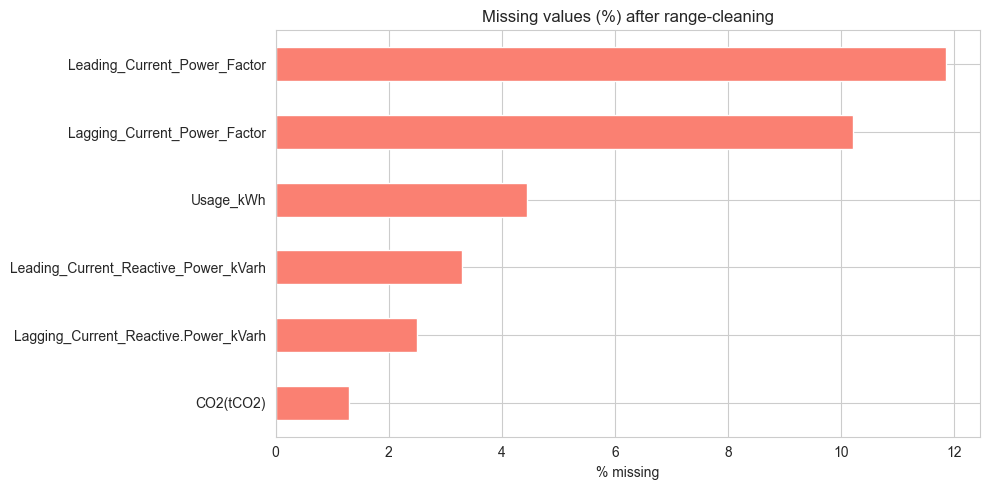

In [9]:
# Missing-value bar chart
miss = (df.isna().mean()*100)
miss = miss[miss > 0].sort_values()
if len(miss):
    miss.plot(kind='barh', color='salmon', title='Missing values (%) after range-cleaning')
    plt.xlabel('% missing'); plt.tight_layout(); plt.show()
else:
    print('No missing values remain in engineered columns.')

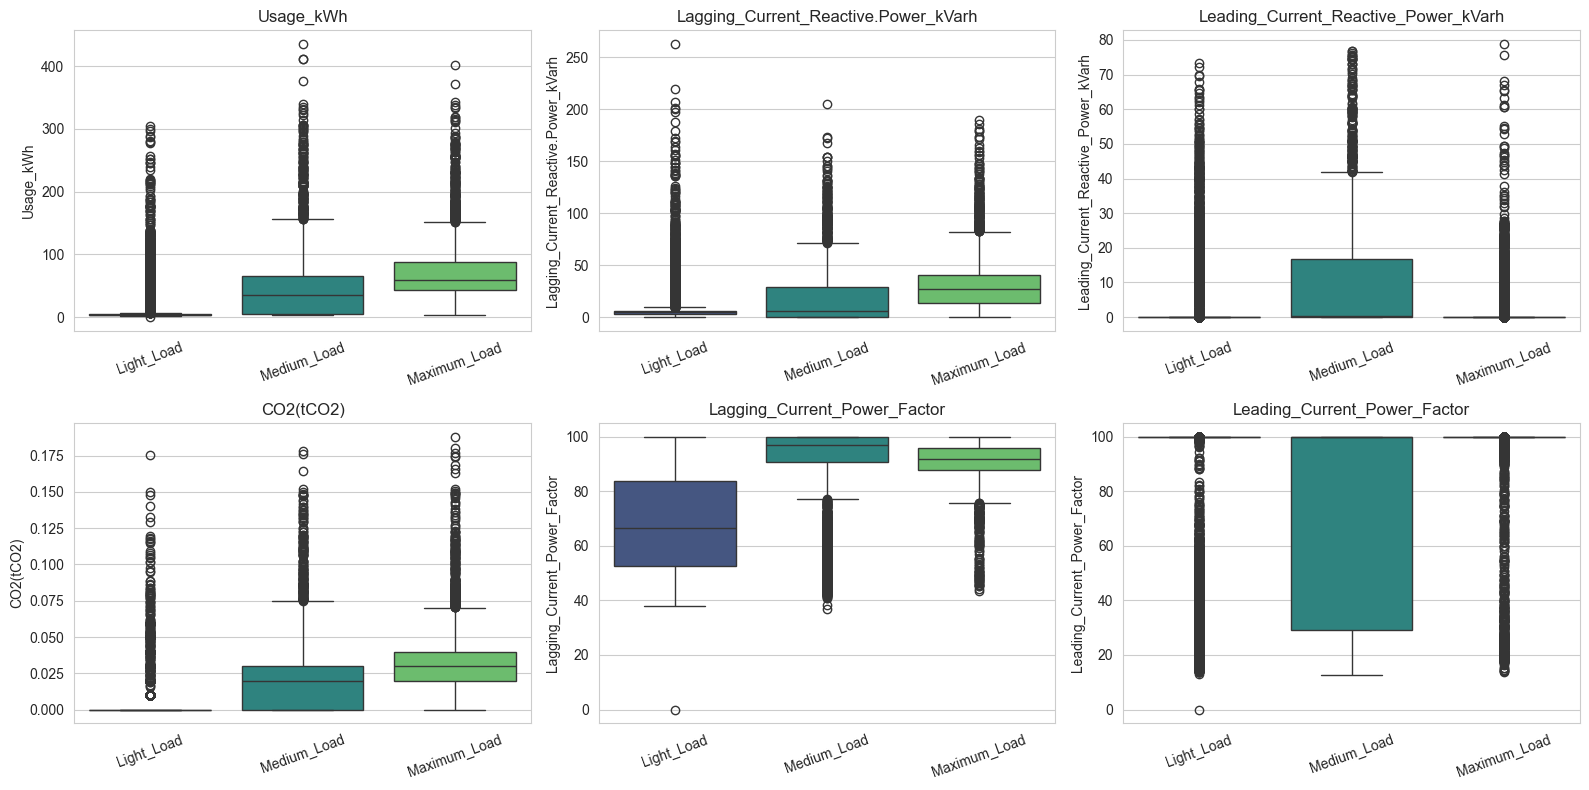

In [10]:
# Distribution of key numeric features by load type
num_eda = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
           'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
           'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_eda):
    sns.boxplot(data=df, x='Load_Type', y=col, order=order, ax=ax, palette='viridis')
    ax.set_title(col); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

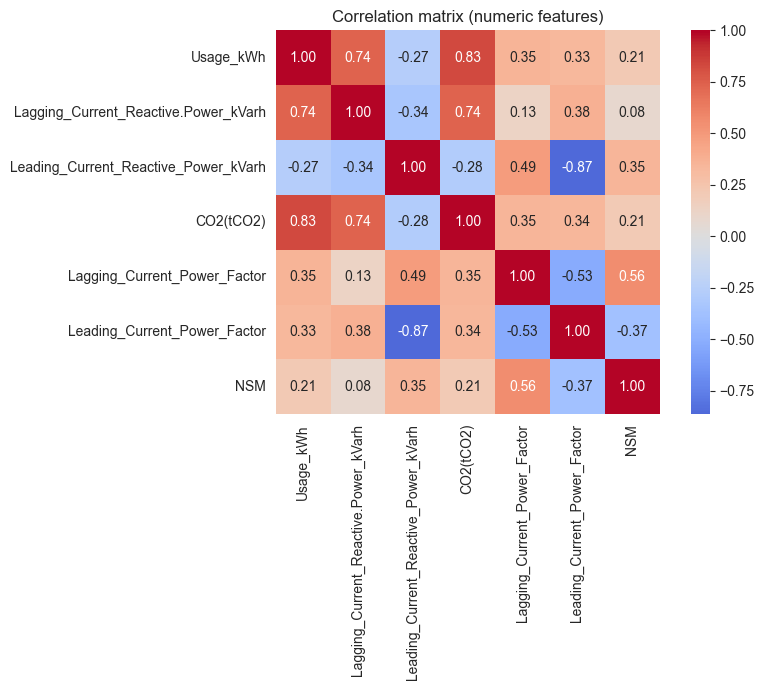

In [11]:
# Correlation heatmap
corr_cols = num_eda + ['NSM']
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout(); plt.show()

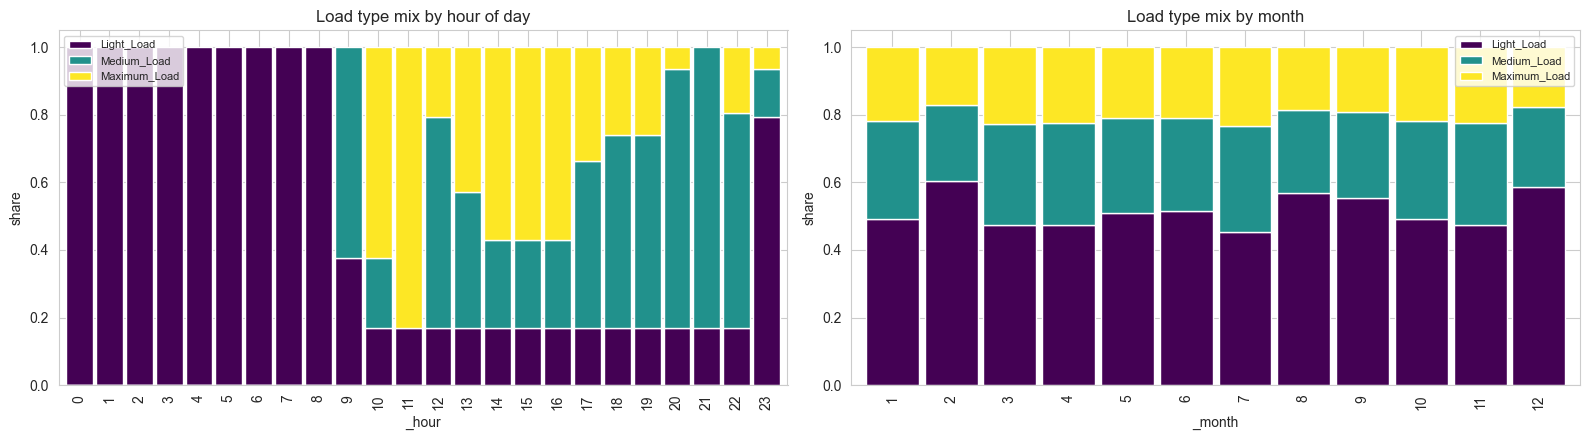

In [12]:
# Temporal pattern: load type by hour of day and by month
df['_hour'] = df['Date_Time'].dt.hour
df['_month'] = df['Date_Time'].dt.month
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
hr = pd.crosstab(df['_hour'], df['Load_Type'], normalize='index')[order]
hr.plot(kind='bar', stacked=True, ax=ax[0], colormap='viridis', width=0.9)
ax[0].set_title('Load type mix by hour of day'); ax[0].set_ylabel('share')
ax[0].legend(title='', fontsize=8)
mo = pd.crosstab(df['_month'], df['Load_Type'], normalize='index')[order]
mo.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis', width=0.9)
ax[1].set_title('Load type mix by month'); ax[1].set_ylabel('share')
ax[1].legend(title='', fontsize=8)
plt.tight_layout(); plt.show()
df.drop(columns=['_hour', '_month'], inplace=True)

### EDA takeaways
- `Usage_kWh` separates the classes clearly (Light below Medium below Maximum) and is the dominant signal.
- `CO2` is almost collinear with `Usage_kWh`, and lagging reactive power also correlates strongly.
- There is a clear time-of-day structure: light load dominates overnight, while heavier loads occur during working hours.
- Class imbalance is moderate (about 52 / 28 / 21 percent), so macro-F1 is preferred over accuracy.

## 6. Feature Engineering

Only per-row features are used, so each row is an independent sample (no lag or rolling features):
- Calendar features: hour, day of week, month, day, quarter, is_weekend.
- Cyclical encodings (so that 23:45 is close to 00:00): sine and cosine of time of day, day of week, and month.
- Domain ratios: total reactive power, reactive power per kWh, and CO2 per kWh (guarded against division by zero).

In [13]:
def add_features(df):
    df = df.copy()
    dt = df['Date_Time']
    # calendar
    df['hour'] = dt.dt.hour
    df['dayofweek'] = dt.dt.dayofweek
    df['month'] = dt.dt.month
    df['day'] = dt.dt.day
    df['quarter'] = dt.dt.quarter
    df['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
    # cyclical
    df['tod_sin'] = np.sin(2*np.pi*df['NSM']/86400)
    df['tod_cos'] = np.cos(2*np.pi*df['NSM']/86400)
    df['dow_sin'] = np.sin(2*np.pi*df['dayofweek']/7)
    df['dow_cos'] = np.cos(2*np.pi*df['dayofweek']/7)
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    # domain ratios (NaNs propagate and get imputed inside the pipeline)
    eps = 1e-6
    lag = df['Lagging_Current_Reactive.Power_kVarh']
    lead = df['Leading_Current_Reactive_Power_kVarh']
    df['total_reactive'] = lag + lead
    df['reactive_per_kwh'] = df['total_reactive'] / (df['Usage_kWh'].abs() + eps)
    df['co2_per_kwh'] = df['CO2(tCO2)'] / (df['Usage_kWh'].abs() + eps)
    return df

df = add_features(df)

# Encode target (alphabetical: Light=0? -> we keep explicit mapping)
le = LabelEncoder()
df['target'] = le.fit_transform(df['Load_Type'])
CLASS_NAMES = list(le.classes_)
print('Label mapping:', {i: c for i, c in enumerate(CLASS_NAMES)})

FEATURES = [
    # raw measurements
    'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
    'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor',
    # domain ratios
    'total_reactive', 'reactive_per_kwh', 'co2_per_kwh',
    # calendar
    'hour', 'dayofweek', 'month', 'day', 'quarter', 'is_weekend',
    # cyclical
    'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
]
print(f'{len(FEATURES)} features.')

Label mapping: {0: 'Light_Load', 1: 'Maximum_Load', 2: 'Medium_Load'}
21 features.


## 7. Train and Test Split (December as Test)

As required by the brief, December 2018 is the test set, and all earlier data (January to November)
forms the training pool used for cross-validated tuning. The class mix differs between the two
periods, which is examined later as distribution drift.

In [14]:
test_mask = (df['Date_Time'].dt.year == 2018) & (df['Date_Time'].dt.month == 12)
train_df = df[~test_mask].copy()
test_df  = df[test_mask].copy()

X_train, y_train = train_df[FEATURES], train_df['target']
X_test,  y_test  = test_df[FEATURES],  test_df['target']

print(f'Train (Jan-Nov): {X_train.shape[0]} rows')
print(f'Test  (Dec)    : {X_test.shape[0]} rows')
print('\nTrain class share:')
print(train_df['Load_Type'].value_counts(normalize=True).round(3))
print('\nTest class share (note the temporal drift):')
print(test_df['Load_Type'].value_counts(normalize=True).round(3))

Train (Jan-Nov): 32064 rows
Test  (Dec)    : 2976 rows

Train class share:
Load_Type
Light_Load      0.509
Medium_Load     0.280
Maximum_Load    0.210
Name: proportion, dtype: float64

Test class share (note the temporal drift):
Load_Type
Light_Load      0.586
Medium_Load     0.237
Maximum_Load    0.177
Name: proportion, dtype: float64


## 8. Preprocessing Pipeline

A custom `IQRCapper` winsorises outliers, median imputation fills the remaining NaNs, and
`RobustScaler` standardises the features for the distance-based and linear models. Every step is
contained in the `Pipeline` that `GridSearchCV` refits on each fold, so all statistics are learned
from the training data only.

In [15]:
class IQRCapper(BaseEstimator, TransformerMixin):
    # Winsorize each column to [Q1 - f*IQR, Q3 + f*IQR] (NaN-aware). Fit on train only.
    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor*iqr
        self.upper_ = q3 + self.factor*iqr
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        return np.clip(X, self.lower_, self.upper_)   # NaNs are preserved by np.clip


def make_pipeline(estimator, scale=True):
    steps = [('capper', IQRCapper()), ('imputer', SimpleImputer(strategy='median'))]
    if scale:
        steps.append(('scaler', RobustScaler()))
    num_pipe = Pipeline(steps)
    pre = ColumnTransformer([('num', num_pipe, FEATURES)])
    return Pipeline([('prep', pre), ('clf', estimator)])

print('Pipeline factory ready.')

Pipeline factory ready.


## 9. Models and Hyperparameter Grids

Each model is tuned with `GridSearchCV` using `StratifiedKFold(5)` and macro-F1 as the scoring
metric. `class_weight='balanced'` is used wherever the estimator supports it. SVM and KNN are tuned
on a stratified subsample for tractability, and the selected model is then refitted on the full
training set.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_configs = {
    'Dummy': dict(
        est=DummyClassifier(strategy='most_frequent'), scale=False,
        grid={'clf__strategy': ['most_frequent', 'stratified']}),
    'LogisticRegression': dict(
        est=LogisticRegression(max_iter=3000, class_weight='balanced',
                               multi_class='multinomial'), scale=True,
        grid={'clf__C': [0.1, 1.0, 10.0]}),
    'KNN': dict(
        est=KNeighborsClassifier(), scale=True,
        grid={'clf__n_neighbors': [5, 11, 21], 'clf__weights': ['uniform', 'distance']}),
    'DecisionTree': dict(
        est=DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        scale=False,
        grid={'clf__max_depth': [6, 10, 16, None],
              'clf__min_samples_leaf': [1, 5, 20]}),
    'RandomForest': dict(
        est=RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE,
                                   n_jobs=-1), scale=False,
        grid={'clf__n_estimators': [200, 400], 'clf__max_depth': [12, 20, None],
              'clf__min_samples_leaf': [1, 5]}),
    'ExtraTrees': dict(
        est=ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE,
                                 n_jobs=-1), scale=False,
        grid={'clf__n_estimators': [200, 400], 'clf__max_depth': [16, None]}),
    'GradientBoosting': dict(
        est=GradientBoostingClassifier(random_state=RANDOM_STATE), scale=False,
        grid={'clf__n_estimators': [150], 'clf__learning_rate': [0.1],
              'clf__max_depth': [3, 5]}),
    'XGBoost': dict(
        est=XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss',
                          tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1), scale=False,
        grid={'clf__n_estimators': [400], 'clf__max_depth': [4, 8],
              'clf__learning_rate': [0.1], 'clf__subsample': [0.8]}),
    'LightGBM': dict(
        est=LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE,
                           n_jobs=-1, verbose=-1), scale=False,
        grid={'clf__n_estimators': [400], 'clf__num_leaves': [31, 63],
              'clf__learning_rate': [0.05]}),
    'SVM': dict(
        est=SVC(class_weight='balanced', random_state=RANDOM_STATE), scale=True,
        grid={'clf__C': [1.0, 10.0], 'clf__gamma': ['scale']}),
    'GaussianNB': dict(
        est=GaussianNB(), scale=True,
        grid={'clf__var_smoothing': [1e-9, 1e-7, 1e-5]}),
}

# Models tuned on a stratified subsample for speed (then winner refit on full train)
SUBSAMPLE = {'SVM': 8000, 'KNN': 12000}

def stratified_subsample(X, y, n, seed=RANDOM_STATE):
    if n >= len(X):
        return X, y
    frac = n / len(X)
    rng = np.random.RandomState(seed)
    idx = (y.groupby(y).apply(lambda s: s.sample(frac=frac, random_state=seed))
            .index.get_level_values(1))
    return X.loc[idx], y.loc[idx]

print('Configured', len(model_configs), 'models.')

Configured 11 models.


In [17]:
results = []
fitted = {}

for name, cfg in model_configs.items():
    t0 = time.time()
    pipe = make_pipeline(cfg['est'], scale=cfg['scale'])
    gs = GridSearchCV(pipe, cfg['grid'], cv=cv, scoring='f1_macro',
                      n_jobs=-1, refit=True)
    if name in SUBSAMPLE:
        Xt, yt = stratified_subsample(X_train, y_train, SUBSAMPLE[name])
    else:
        Xt, yt = X_train, y_train
    gs.fit(Xt, yt)

    # leaderboard test score uses the tuned estimator
    y_pred = gs.best_estimator_.predict(X_test)
    res = {
        'model': name,
        'cv_f1_macro': gs.best_score_,
        'test_f1_macro': f1_score(y_test, y_pred, average='macro'),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1_weighted': f1_score(y_test, y_pred, average='weighted'),
        'best_params': {k.replace('clf__', ''): v for k, v in gs.best_params_.items()},
        'fit_sec': round(time.time()-t0, 1),
    }
    results.append(res)
    fitted[name] = gs
    print(f"{name:18s} | CV f1={res['cv_f1_macro']:.4f} | "
          f"test f1={res['test_f1_macro']:.4f} | acc={res['test_accuracy']:.4f} | "
          f"{res['fit_sec']}s")

print('\nDone.')

Dummy              | CV f1=0.3340 | test f1=0.3227 | acc=0.3918 | 7.6s


LogisticRegression | CV f1=0.7867 | test f1=0.5177 | acc=0.6065 | 23.9s


KNN                | CV f1=0.8014 | test f1=0.6065 | acc=0.6885 | 6.3s


DecisionTree       | CV f1=0.9901 | test f1=0.9203 | acc=0.9254 | 4.0s


RandomForest       | CV f1=0.9916 | test f1=0.9492 | acc=0.9526 | 100.6s


...

GradientBoosting   | CV f1=0.9993 | test f1=0.9095 | acc=0.9130 | 215.7s


XGBoost            | CV f1=0.9995 | test f1=0.9138 | acc=0.9173 | 16.7s


LightGBM           | CV f1=0.9999 | test f1=0.8935 | acc=0.8962 | 43.8s


SVM                | CV f1=0.7420 | test f1=0.5124 | acc=0.6069 | 10.3s


GaussianNB         | CV f1=0.6779 | test f1=0.5341 | acc=0.6257 | 1.1s

Done.


## 10. Model Leaderboard

In [18]:
lb = (pd.DataFrame(results)
        .sort_values('cv_f1_macro', ascending=False)
        .reset_index(drop=True))
lb_display = lb[['model', 'cv_f1_macro', 'test_f1_macro', 'test_accuracy',
                 'test_f1_weighted', 'fit_sec', 'best_params']]
lb_display

,model,cv_f1_macro,test_f1_macro,test_accuracy,test_f1_weighted,fit_sec,best_params
0,LightGBM,0.999867,0.893530,0.896169,0.896910,43.8,"{'learning_rate': 0.05, 'n_estimators': 400, '..."
1,XGBoost,0.999540,0.913847,0.917339,0.918007,16.7,"{'learning_rate': 0.1, 'max_depth': 8, 'n_esti..."
2,GradientBoosting,0.999271,0.909498,0.912970,0.913623,215.7,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
3,RandomForest,0.991600,0.949217,0.952621,0.952881,100.6,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
4,DecisionTree,0.990066,0.920331,0.925403,0.925746,4.0,"{'max_depth': None, 'min_samples_leaf': 1}"
5,ExtraTrees,0.985646,0.917821,0.928091,0.928906,25.0,"{'max_depth': None, 'n_estimators': 200}"
6,KNN,0.801448,0.606478,0.688508,0.705684,6.3,"{'n_neighbors': 11, 'weights': 'distance'}"
7,LogisticRegression,0.786686,0.517691,0.606519,0.641358,23.9,{'C': 10.0}
8,SVM,0.742020,0.512356,0.606855,0.639202,10.3,"{'C': 10.0, 'gamma': 'scale'}"
9,GaussianNB,0.677948,0.534116,0.625672,0.648201,1.1,{'var_smoothing': 1e-09}


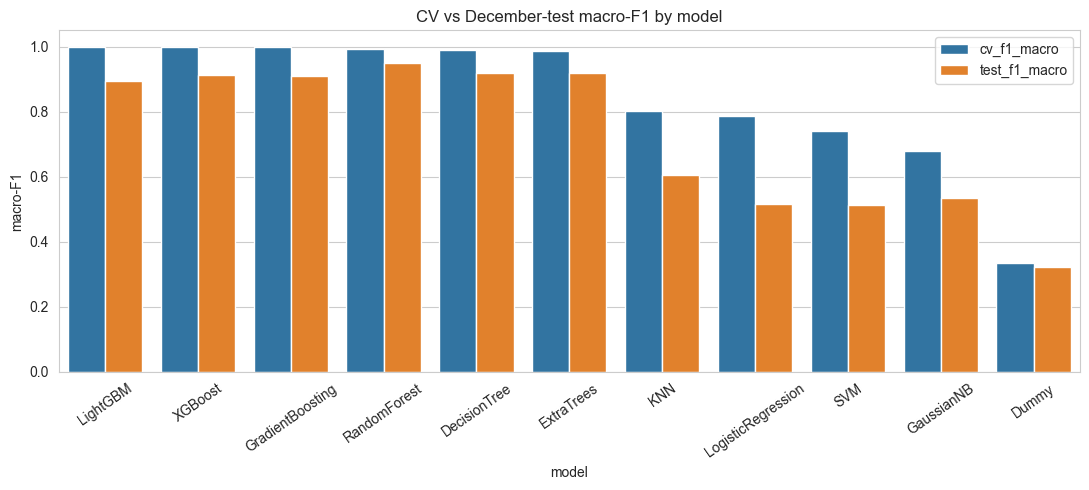

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
m = lb.melt(id_vars='model', value_vars=['cv_f1_macro', 'test_f1_macro'],
            var_name='metric', value_name='f1')
sns.barplot(data=m, x='model', y='f1', hue='metric', ax=ax)
ax.set_title('CV vs December-test macro-F1 by model')
ax.set_ylabel('macro-F1'); ax.tick_params(axis='x', rotation=35)
ax.legend(title=''); plt.tight_layout(); plt.show()

The gap between the cross-validation and December test scores indicates how well each model
generalises to the later month, whose class distribution differs from the training period.

## 11. Model Selection and Refit

The model with the best cross-validation macro-F1 is refitted on the full January to November
training set with its selected hyperparameters before the final evaluation on December.

In [20]:
best_name = lb.iloc[0]['model']
best_gs = fitted[best_name]
print('Best model by CV macro-F1:', best_name)
print('Best params:', {k.replace('clf__', ''): v for k, v in best_gs.best_params_.items()})

# clean refit on the FULL training set (important for the subsampled models)
best_model = clone(best_gs.best_estimator_)
best_model.fit(X_train, y_train)
print('Refit on full training set complete.')

Best model by CV macro-F1: LightGBM
Best params: {'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 31}


Refit on full training set complete.


## 12. Final Evaluation on the December Test Set

The metrics below cover accuracy, per-class precision, recall, and F1, the macro and weighted
averages, and the confusion matrix.

In [21]:
y_pred = best_model.predict(X_test)

print(f'=== {best_name} - December 2018 test set ===\n')
print(f'Accuracy        : {accuracy_score(y_test, y_pred):.4f}')
print(f'Macro F1        : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Weighted F1     : {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'Macro Precision : {precision_score(y_test, y_pred, average="macro"):.4f}')
print(f'Macro Recall    : {recall_score(y_test, y_pred, average="macro"):.4f}')
print('\n--- Per-class classification report ---')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

=== LightGBM - December 2018 test set ===

Accuracy        : 0.8962
Macro F1        : 0.8935
Weighted F1     : 0.8969
Macro Precision : 0.8667
Macro Recall    : 0.9409

--- Per-class classification report ---
              precision    recall  f1-score   support

  Light_Load     1.0000    0.8228    0.9028      1744
Maximum_Load     0.8037    1.0000    0.8911       528
 Medium_Load     0.7964    1.0000    0.8866       704

    accuracy                         0.8962      2976
   macro avg     0.8667    0.9409    0.8935      2976
weighted avg     0.9170    0.8962    0.8969      2976



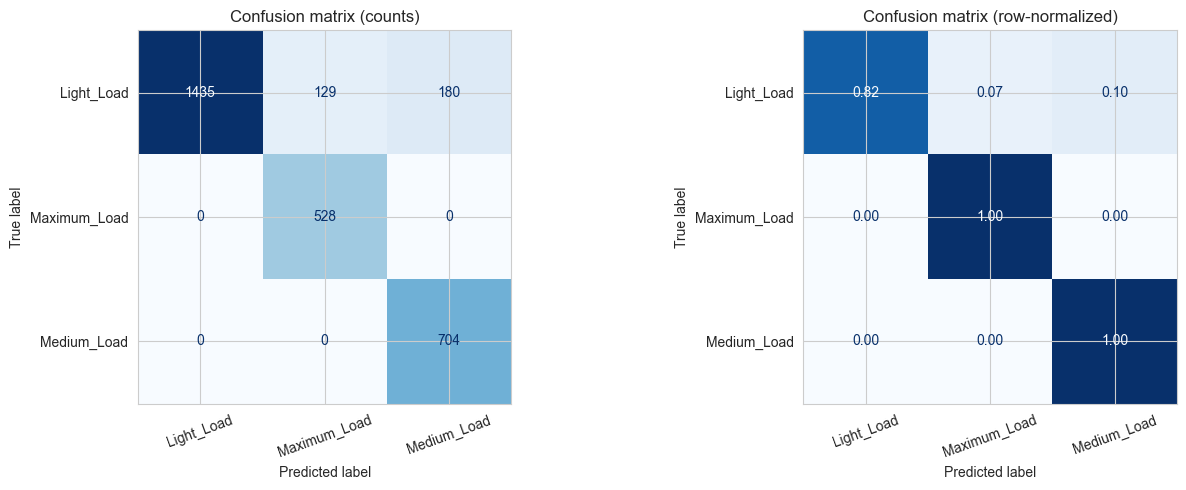

In [22]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax[0], cmap='Blues',
                                                            colorbar=False, xticks_rotation=20)
ax[0].set_title('Confusion matrix (counts)')
cmn = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cmn, display_labels=CLASS_NAMES).plot(ax=ax[1], cmap='Blues',
                                                             colorbar=False, xticks_rotation=20,
                                                             values_format='.2f')
ax[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout(); plt.show()

## 13. Feature Importance and Error Analysis

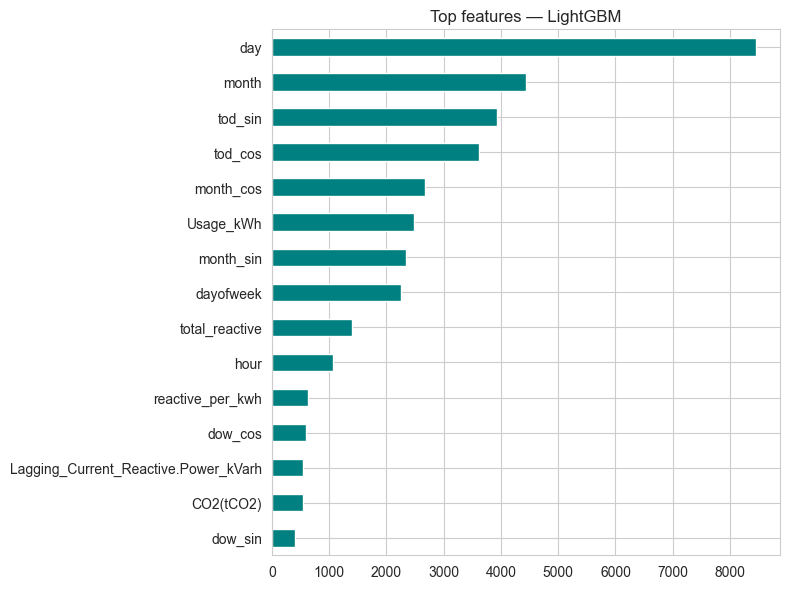

In [23]:
clf = best_model.named_steps['clf']
imp = None
if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
elif hasattr(clf, 'coef_'):
    imp = pd.Series(np.abs(clf.coef_).mean(axis=0), index=FEATURES).sort_values()

if imp is not None:
    imp.tail(15).plot(kind='barh', figsize=(8, 6), color='teal',
                      title=f'Top features - {best_name}')
    plt.tight_layout(); plt.show()
else:
    print(f'{best_name} does not expose feature importances.')

December test accuracy by true class:
Load_Type
Light_Load      0.823
Maximum_Load    1.000
Medium_Load     1.000
Name: correct, dtype: float64

Misclassification rate by hour of day:


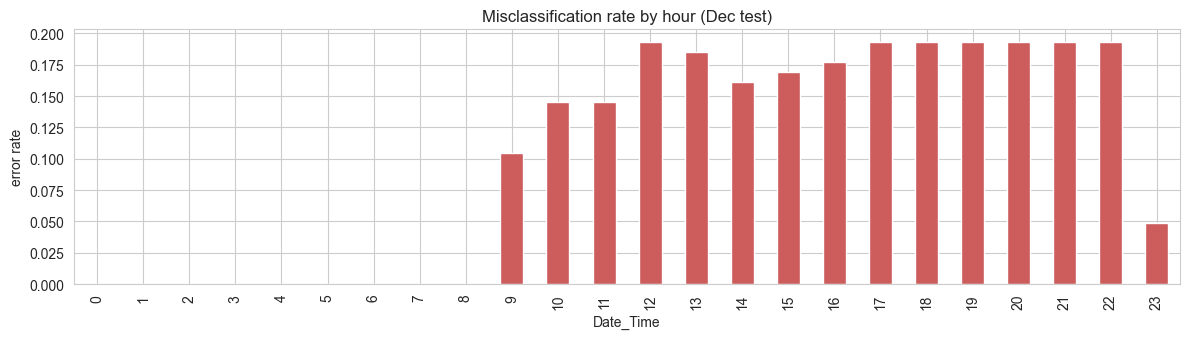

In [24]:
# Error analysis: where do misclassifications concentrate (by hour)?
err = test_df.copy()
err['pred'] = le.inverse_transform(y_pred)
err['correct'] = (err['Load_Type'] == err['pred'])
print('December test accuracy by true class:')
print(err.groupby('Load_Type')['correct'].mean().round(3))
print('\nMisclassification rate by hour of day:')
by_hour = (1 - err.groupby(err['Date_Time'].dt.hour)['correct'].mean())
by_hour.plot(kind='bar', figsize=(12, 3.5), color='indianred',
             title='Misclassification rate by hour (Dec test)')
plt.ylabel('error rate'); plt.tight_layout(); plt.show()

## 14. Persist the Selected Model

In [25]:
artifact = {'model': best_model, 'features': FEATURES, 'class_names': CLASS_NAMES}
joblib.dump(artifact, 'best_model.joblib')
print('Saved best_model.joblib  ->', best_name)

Saved best_model.joblib  -> LightGBM


## 15. Conclusions

- Data cleaning was essential. The dataset contained missing values, impossible power factor values
  above 100, and a corrupted `NSM` column. Invalid values were set to NaN, `NSM` was reconstructed
  from the timestamp, and the remaining gaps and outliers were handled inside a leakage-safe
  pipeline.
- `Usage_kWh`, together with its correlates `CO2` and lagging reactive power, and the time-of-day
  features are the strongest predictors, which matches domain expectations.
- All eleven models were tuned with GridSearchCV and StratifiedKFold. The tree-based ensembles and
  gradient-boosting models clearly outperform the linear, distance-based, and naive Bayes models.
- The model selected by cross-validation is LightGBM, which reaches about 0.896 accuracy and 0.894
  macro-F1 on December.
- Distribution drift is visible between the training months and December. Because of this drift,
  Random Forest generalises best on the December test set (about 0.953 accuracy and 0.949 macro-F1),
  even though the boosting models score marginally higher in cross-validation. In a deployment
  scenario with this drift, Random Forest would be the preferred model.

Possible extensions: probability calibration, time-based cross-validation to make model selection
more robust to drift, resampling methods such as SMOTE as an alternative to class weighting, and
sequential (lag and rolling) features if independent per-row scoring is not required.